# Прогноз потока кандидатов 2025-2027: Modeling

## Описание задачи
Датасет содержит HR-метрики и данные о найме IT-специалистов
в 505 департаментах крупной компании за 2020-2024 гг.

**Цель:** предсказать суммарный поток кандидатов до 2027 года
для планирования нагрузки на рекрутинг.

**Целевая переменная:** `yearly_cv_processed` — количество
обработанных резюме в год на департамент.

## Описание данных
| Колонка | Описание |
|---------|----------|
| department_id | ID департамента |
| year | Год наблюдения |
| tech_stack | Тип объекта (аэропорт, стадион и т.д.) |
| current_staff_count | Текущая численность IT-персонала |
| yearly_cv_processed | Обработано резюме за год (целевая) |
| active_projects_count | Количество активных проектов |
| devs_hired / devs_fired | Нанято / уволено разработчиков |
| turnover_rate | Коэффициент текучести кадров |
| avg_dev_salary | Средняя зарплата разработчика |
| total_salary_budget | Общий бюджет на зарплаты |
| tech_brand_rating | Рейтинг технического бренда |
| inbound_applications | Входящие заявки |
| share_seniors | Доля сеньоров |

## Структура ноутбука
1. Подготовка данных
2. Моделирование — Ridge с walk-forward валидацией
3. Прогноз — итеративное предсказание на 2025-2027

Исследование данных находится в ``01_eda.ipynb``. Здесь используется только итоговая реализация из ``src/``

In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

In [2]:
import pandas as pd

from src.data import load_data, clean_data, build_features
from src.modeling import run_cv, get_coefficients, train_final_model, forecast_future
from src.viz import plot_forecast
from src import config

In [3]:
data = build_features(clean_data(load_data()))

In [4]:
data[config.NUM_FEATURES].isna().sum()

yearly_cv_processed_lag1      505
active_projects_count_lag1    505
active_projects_delta1        505
net_hiring                      0
tech_brand_rating               0
dtype: int64

In [5]:
data.head()

,department_id,year,tech_stack,current_staff_count,yearly_cv_processed,share_seniors,active_projects_count,inbound_applications,avg_dev_salary,devs_hired,devs_fired,turnover_rate,tech_brand_rating,total_salary_budget,yearly_cv_processed_lag1,active_projects_count_lag1,active_projects_delta1,net_hiring
0,1000000.0,2020.0,Стадион,392.0,5847.0,4.591837,231.0,1969.0,110277.784723,77.0,52.0,0.329082,0.6,51877245.0,NaN,NaN,NaN,25.0
1,1000000.0,2021.0,Стадион,445.0,6688.0,6.292135,258.0,2415.0,123862.871896,119.0,47.0,0.373034,0.6,66162037.0,5847.0,231.0,27.0,72.0
2,1000000.0,2022.0,Стадион,514.0,7503.0,7.198444,291.0,2544.0,122932.673766,143.0,60.0,0.394942,0.6,75827728.0,6688.0,258.0,33.0,83.0
3,1000000.0,2023.0,Стадион,587.0,8272.0,8.858603,327.0,3426.0,123735.907223,103.0,63.0,0.282794,0.8,87165251.0,7503.0,291.0,36.0,40.0
4,1000000.0,2024.0,Стадион,632.0,9267.0,11.550633,362.0,3318.0,141861.433957,91.0,96.0,0.295886,0.2,107592482.0,8272.0,327.0,35.0,-5.0


# Обучение модели

Данные представляют собой панельную структуру: 505 департаментов × 5 лет.
Это слишком мало точек на один департамент для классических методов временных рядов (Prophet, ARIMA),
поэтому строим одну модель на всех департаментах сразу

**Выбранная модель:** Ridge регрессия - устойчива к мультиколлинеарности
между признаками

**Валидация:** walk-forward - трейн всегда предшествует тесту по времени:
- Фолд 1: обучение 2021 → тест 2022
- Фолд 2: обучение 2021-2022 → тест 2023
- Фолд 3: обучение 2021-2023 → тест 2024

## Кросс-валидация и обучение

Преобразования (OneHotEncoder, StandardScaler) и Ridge собраны в пайплайне (см. ``src/modeling.py``). 

In [6]:
fold_metrics, last_model = run_cv(data, config.CV_FOLDS)

Результаты предсказания 2022
MAE:53.74324934227203
R2:0.9960812468387875

Результаты предсказания 2023
MAE:56.482537702725445
R2:0.9958104586404616

Результаты предсказания 2024
MAE:55.65665378545223
R2:0.9968128294565408



In [7]:
coef_df = get_coefficients(last_model)
coef_df

,feature,coefficient
14,num__yearly_cv_processed_lag1,1157.503230
16,num__active_projects_delta1,187.031837
15,num__active_projects_count_lag1,51.410004
5,cat__tech_stack_Метро,-17.162492
11,cat__tech_stack_Торговый_центр,-16.022188
6,cat__tech_stack_Парк,-12.382135
3,cat__tech_stack_ЖД_станция,-12.373045
10,cat__tech_stack_Стадион,-11.828938
4,cat__tech_stack_Жилой_район,-9.647797
17,num__net_hiring,8.078961


Числовые признаки отмасштабированы, поэтому их коэффициенты сравнимы. 

Доминирует ``yearly_cv_processed_lag1``

## Результаты валидации

| Год теста | MAE | R² |
|-----------|-----|----|
| 2022 | ~54 | 0.996 |
| 2023 | ~57 | 0.996 |
| 2024 | ~55 | 0.997 |

Средняя ошибка ~55 резюме при медиане 2000 - погрешность 2.7%.

Высокий R² объясняется лагом таргета: нагрузка департамента меняется несильно. Чтобы оценить реальный вклад модели, ее стоит сравнить с наивных прогнозом

## Финальное обучение

После валидации переобучаем модель на всех доступных данных 2021-2024

In [8]:
model = train_final_model(data)

## Прогноз 2025-2027

Используем итеративный подход: предсказание каждого года становится
лаговым признаком для следующего

- 2024 (факт) → предсказываем 2025
- 2025 (прогноз) → предсказываем 2026
- 2026 (прогноз) → предсказываем 2027

In [9]:
results = forecast_future(data, model, config.FORECAST_YEARS)

In [10]:
for year, preds in results.items():
    print(f"{year}: {preds.sum():,.0f}")

2025: 1,137,011
2026: 1,147,248
2027: 1,157,212


## Итоговый прогноз

| Год | CV (сумма) | Прирост |
|-----|-----------|---------|
| 2024 (факт) | 1,126,493 | - |
| 2025 | 1,137,011 | +10,518 |
| 2026 | 1,147,248 | +10,237 |
| 2027 | 1,157,212 | +9,964 |

In [11]:
forecast_df = pd.DataFrame({
    'year': config.FORECAST_YEARS,
    'yearly_cv_processed': [preds.sum() for preds in results.values()],
})

forecast_df

,year,yearly_cv_processed
0,2025,1.137011e+06
1,2026,1.147248e+06
2,2027,1.157212e+06


In [12]:
hist_df = data.groupby('year')['yearly_cv_processed'].sum().reset_index()
hist_df

,year,yearly_cv_processed
0,2020.0,1000442.0
1,2021.0,1052243.0
2,2022.0,1089940.0
3,2023.0,1112104.0
4,2024.0,1126493.0


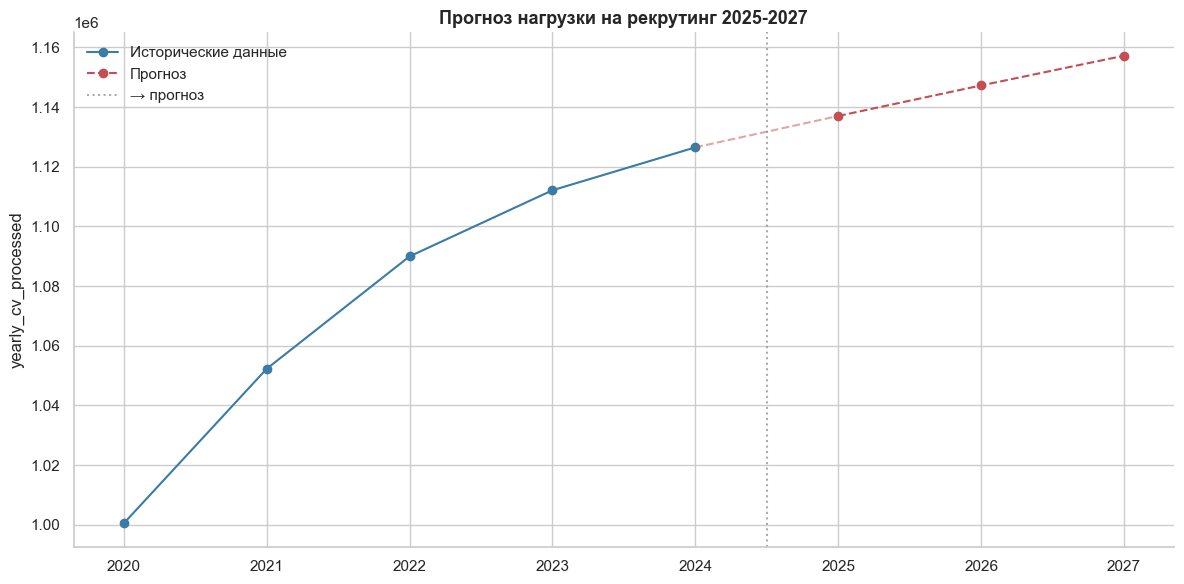

In [13]:
plot_forecast(hist_df, forecast_df)

In [14]:
config.OUTPUT_DIR.mkdir(exist_ok=True)
forecast_df.to_csv(config.OUTPUT_DIR / 'forecast_2025_2027.csv', index=False)
forecast_df.to_excel(config.OUTPUT_DIR / 'forecast_2025_2027.xlsx', index=False)

# Общий вывод по ноутбуку

## Прогноз 2025-2027
| Год | CV (сумма) | Прирост |
|-----|-----------|---------|
| 2024 (факт) | 1,126,493 | - |
| 2025 | 1,137,011 | +10,518 |
| 2026 | 1,147,248 | +10,237 |
| 2027 | 1,157,212 | +9,964 |

Тренд замедляющийся - соответствует историческим данным.

Рекрутинговая нагрузка продолжит умеренный рост ~10 тыс. резюме в год.

## Ограничения и планы

- Сравнить с нативным baseline
- net_hiring заменить на лаг
- Медианное значение пропусков использует будущие годы
- Прогноз держит проекты и рейтинг постоянными